In [1]:
import pandas as pd

In [3]:
df = pd.read_excel("Cleaned_Crypto_Info.xlsx")

In [4]:
df.head()

,open_time,open,high,low,close,volume,volume_usd,num_trades,close_time,Daily_Return_pct,MA_10,MA_20
0,2025-03-25,87498.16,88539.63,86310.00,87392.87,22643.25248,1.979572e+09,2802815,2025-03-25,-0.12,NaN,NaN
1,2025-03-26,87392.88,88275.00,85860.00,86909.17,18408.78485,1.606407e+09,2380154,2025-03-26,-0.55,NaN,NaN
2,2025-03-27,86909.17,87756.39,85800.00,87232.01,17098.03897,1.487969e+09,2376381,2025-03-27,0.37,NaN,NaN
3,2025-03-28,87232.01,87515.67,83585.00,84424.38,27182.73169,2.309947e+09,3236085,2025-03-28,-3.22,NaN,NaN
4,2025-03-29,84424.38,84624.73,81644.81,82648.54,11696.39864,9.701999e+08,2172387,2025-03-29,-2.10,NaN,NaN


In [6]:
df['open_time'] = pd.to_datetime(df['open_time'])

# Select only required columns
prophet_df = df[['open_time', 'close']]

# Rename columns for Prophet
prophet_df.columns = ['ds', 'y']

# Check data
prophet_df.head()

,ds,y
0,2025-03-25,87392.87
1,2025-03-26,86909.17
2,2025-03-27,87232.01
3,2025-03-28,84424.38
4,2025-03-29,82648.54


In [8]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 10.3 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 29.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.1 MB 23.7 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 17.9 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 15.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 23.2 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   -------- ------------------------------- 1/5 [importlib_resources]
   -------- ------------------------------- 1/5 [importlib_resources]
   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [ho

In [9]:
from prophet import Prophet

# Create model
model = Prophet()

# Train model
model.fit(prophet_df)

10:23:30 - cmdstanpy - INFO - Chain [1] start processing
10:23:30 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# Create future dates (next 30 days)
future = model.make_future_dataframe(periods=30)

# Predict future values
forecast = model.predict(future)

# Show predictions
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
363,2026-04-17,58729.990207,52496.156537,64804.584052
364,2026-04-18,57933.037624,51377.611451,64637.630419
365,2026-04-19,57899.567683,52359.880690,64765.113537
366,2026-04-20,57856.459643,51678.155364,64264.519893
367,2026-04-21,57604.780074,51429.408681,63841.759489


In [11]:
# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)

# Generate forecast
forecast = model.predict(future)

# Show output
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
363,2026-04-17,58729.990207,52116.744538,64709.615193
364,2026-04-18,57933.037624,51427.600244,64044.620601
365,2026-04-19,57899.567683,51905.164466,64351.138568
366,2026-04-20,57856.459643,51522.155881,63924.649649
367,2026-04-21,57604.780074,51398.448188,64274.236875


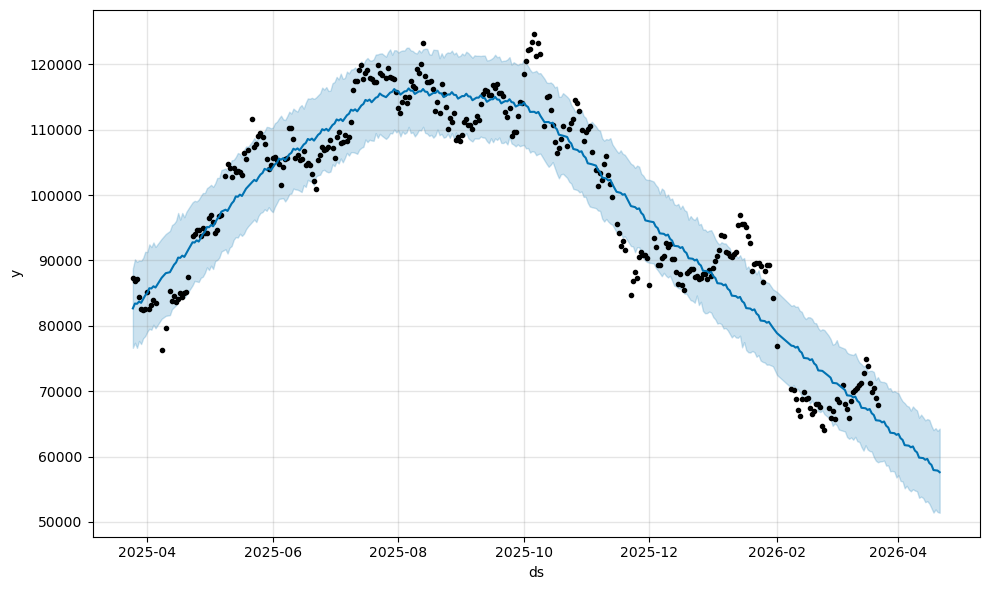

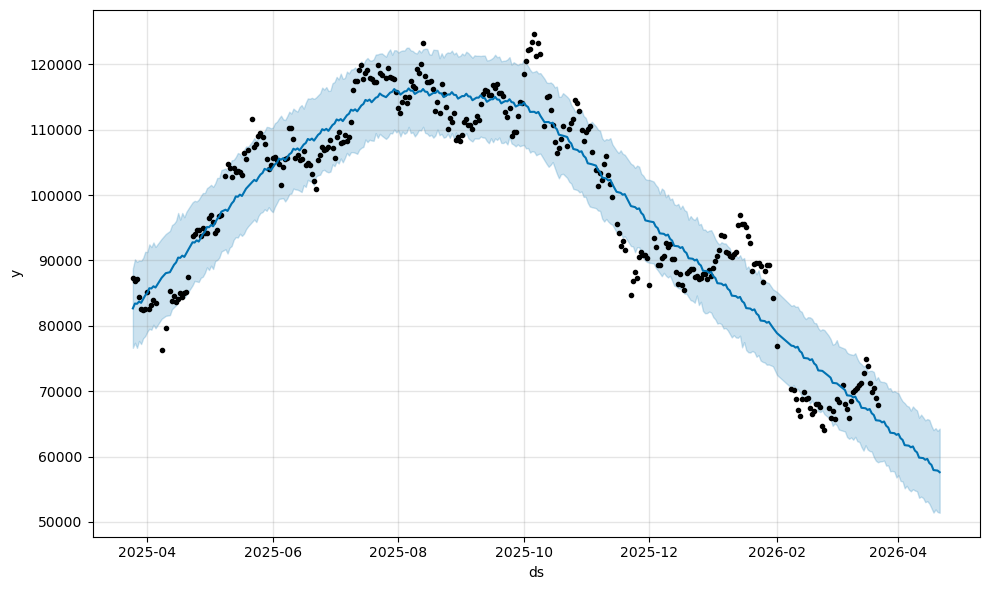

In [12]:
model.plot(forecast)

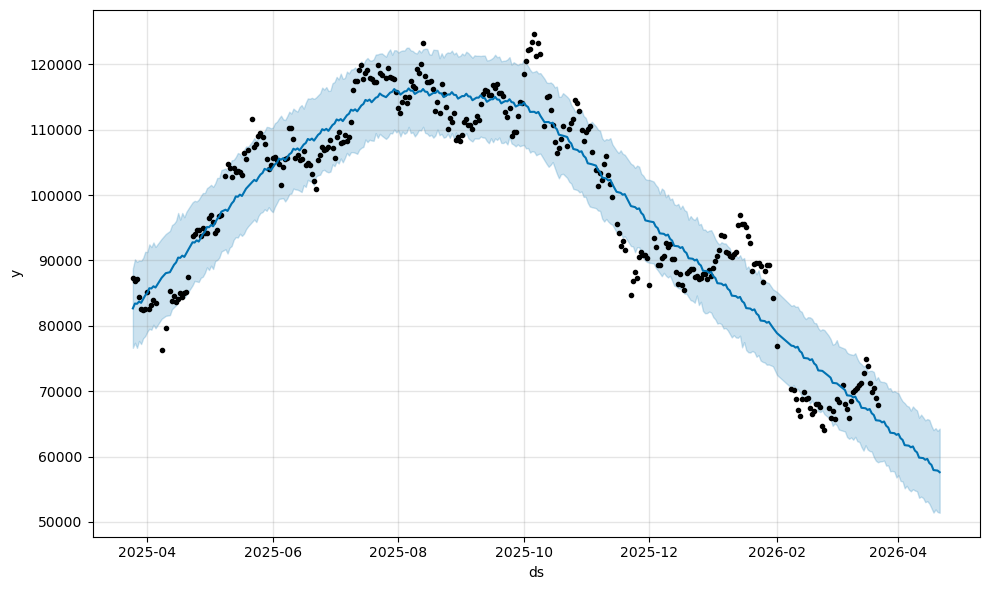

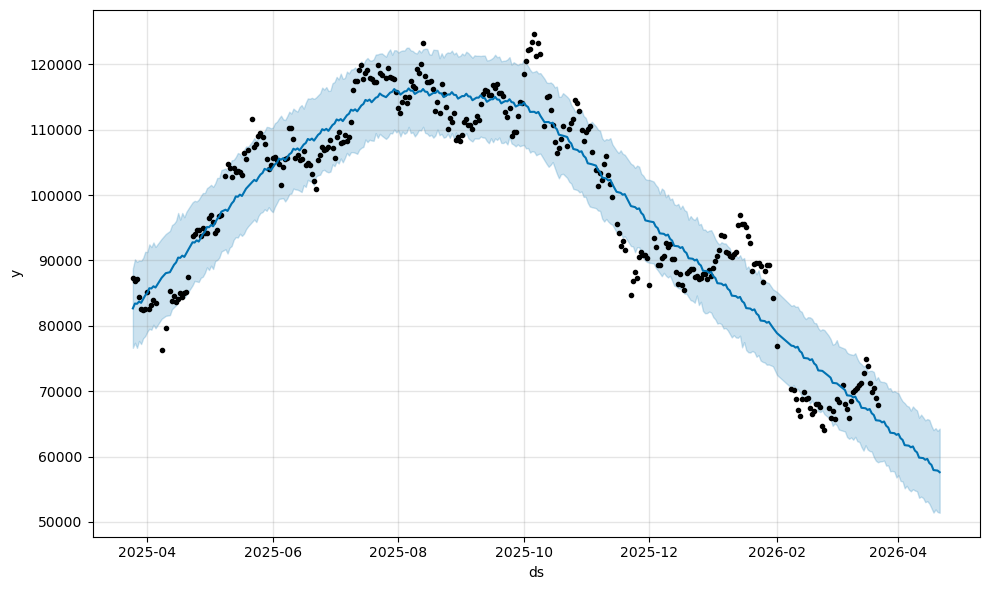

In [13]:
model.plot(forecast)

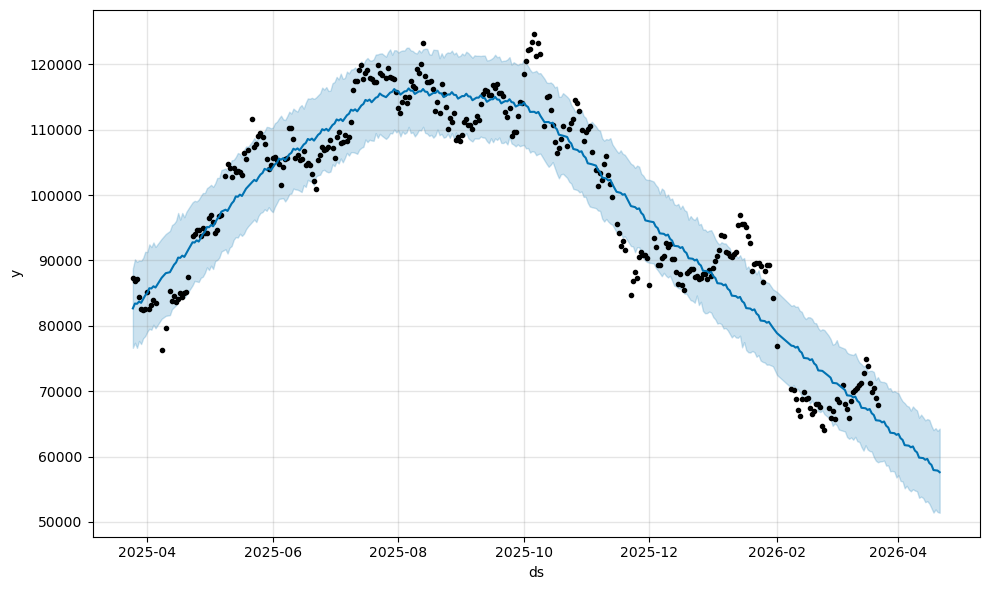

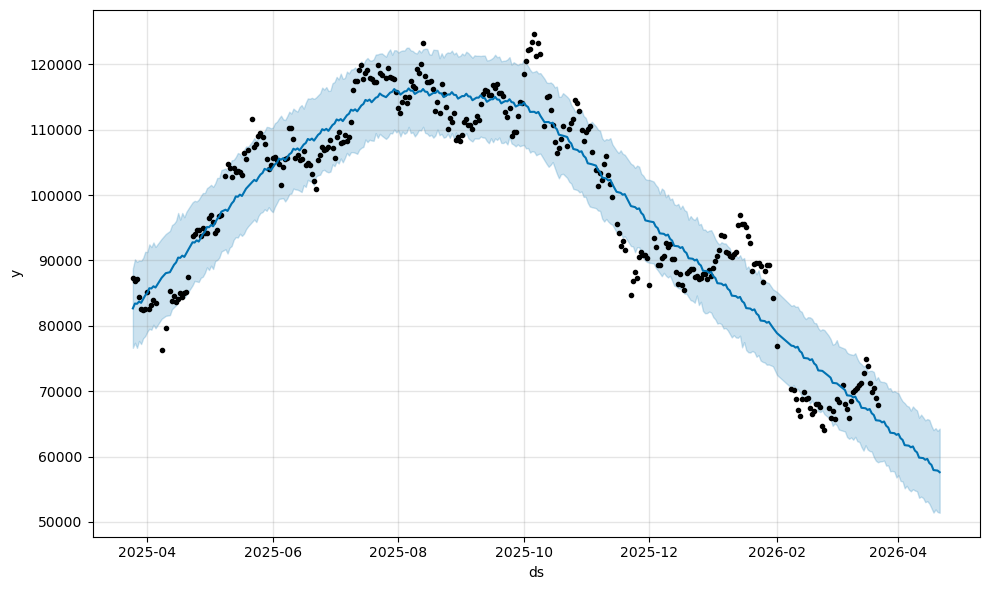

In [14]:
model.plot(forecast) 

In [17]:
forecast.to_csv("forecast_output.csv", index=False)

In [18]:
print(df.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'volume_usd',
       'num_trades', 'close_time', 'Daily_Return_pct', 'MA_10', 'MA_20'],
      dtype='object')


In [19]:
# Convert to Prophet format
df['ds'] = pd.to_datetime(df['open_time'])
df['y'] = df['close']

In [20]:
comparison = forecast.merge(df, on='ds', how='left')

comparison = comparison.rename(columns={
    'y': 'actual_price',
    'yhat': 'predicted_price'
})

comparison = comparison[['ds', 'actual_price', 'predicted_price']]

comparison.tail()

,ds,actual_price,predicted_price
363,2026-04-17,NaN,58729.990207
364,2026-04-18,NaN,57933.037624
365,2026-04-19,NaN,57899.567683
366,2026-04-20,NaN,57856.459643
367,2026-04-21,NaN,57604.780074


In [21]:
comparison.to_csv("forecast_vs_actual.csv", index=False)

In [22]:
comparison_clean = comparison.dropna()
comparison_clean.tail()

,ds,actual_price,predicted_price
333,2026-03-18,71246.54,67270.128892
334,2026-03-19,69930.00,66624.403356
335,2026-03-20,70510.73,66354.621287
336,2026-03-21,68918.12,65557.668704
337,2026-03-22,67859.00,65524.198763


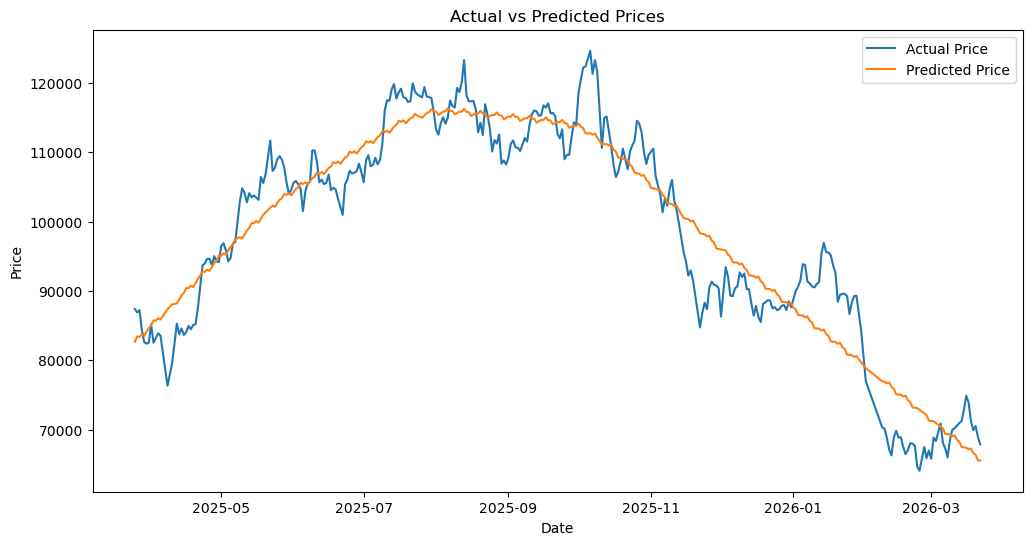

In [23]:
import matplotlib.pyplot as plt

# Use only rows where actual values exist
plot_data = comparison.dropna()

plt.figure(figsize=(12,6))

# Actual values
plt.plot(plot_data['ds'], plot_data['actual_price'], label='Actual Price')

# Predicted values
plt.plot(plot_data['ds'], plot_data['predicted_price'], label='Predicted Price')

# Labels
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")

plt.legend()

plt.show()

In [26]:
import sqlite3

conn = sqlite3.connect("crypto_forecast.db")

forecast.to_sql("forecast_data", conn, if_exists="replace", index=False)
comparison.to_sql("forecast_vs_actual", conn, if_exists="replace", index=False)

368